# Selection effects in the Bagetakos et al. 2011 HI-hole "Type" taxonomy

[B11](Papers/Bagetakos_2011_AJ_141_23.pdf) sorts 1046 HI holes across 20 THINGS galaxies into three Types, based only on whether the expansion velocity $V_{\mathrm{exp}}$ can be measured. So the real question is: are those Types three genuinely different kinds of shell, or just a side effect of what we can detect?

- **Type 1** ($n=625$): can't measure $V_{\mathrm{exp}}$, so B11 assume the hole has stalled and set $V_{\mathrm{exp}} = \sigma_{\mathrm{gas}} \approx 8$ km/s.
- **Type 2** ($n=260$): $V_{\mathrm{exp}}$ measured on one rim. **Type 3** ($n=161$): measured on both rims.
- $H_0$ says it's one population and the label just tracks detectability. $H_1$ says the Types really differ in $R$, $n_{\mathrm{HI}}$, $M_{\mathrm{HI}}$, and geometry, beyond what resolution and distance can explain.

Sections 2 through 5 run five tests, and Section 6 adds them up into a verdict and a recommendation for the pipeline.

In [24]:
from __future__ import annotations

import sys
import warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as st
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestClassifier

def _find_pkg_root() -> Path | None:
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "hishells_pv").is_dir():
            return cand
        if (cand / "hishells-pv-github" / "hishells_pv").is_dir():
            return cand / "hishells-pv-github"
    return None

_PKG_ROOT = _find_pkg_root()
if _PKG_ROOT is not None and str(_PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(_PKG_ROOT))

from hishells_pv.catalog.shell_catalog import load_bagetakos_table7

def _find_table(filename: str) -> Path:
    bases = [_PKG_ROOT] if _PKG_ROOT is not None else []
    bases += [Path.cwd(), *Path.cwd().parents]
    for base in bases:
        for sub in ("data", "Data"):
            cand = base / sub / "J_AJ_141_23" / filename
            if cand.exists():
                return cand
    raise FileNotFoundError(f"Could not locate data/J_AJ_141_23/{filename}")

TABLE7_PATH = _find_table("table7.dat")
TABLE2_PATH = _find_table("table2.dat")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

# colors
RNG = np.random.default_rng(42)
TYPE_COLORS = {1: "#d95f02", 2: "#1b9e77", 3: "#7570b3"}
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# figure export: 300 dpi PNGs written to <pkg_root>/plots/catalog
PLOTS_DIR = ((_PKG_ROOT or Path.cwd()) / "plots" / "catalog")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SAVE_KW = dict(dpi=300, bbox_inches="tight", facecolor="white")

## 1. Catalog data

Load the two CDS tables ([`J/AJ/141/23`](data/J_AJ_141_23)), Table 7 (one row per hole) and Table 2 (one row per galaxy), and merge them. Three preprocessing choices matter later on:

- **`nHI` is really log density.** It has negative values, so it's actually $\log_{10}(n_{\mathrm{HI}}/\mathrm{cm}^{-3})$. We rename it `log_nHI`.
- **Type 1 `V_exp` is assumed, not measured** (it just stores $\sigma_{\mathrm{gas}}$), so we mask it to NaN. The columns derived from it, $t_{\mathrm{kin}}$ and $\log E$, get dropped from the Section 4 features too.
- **Detectability proxy** `dpc_over_res = d_pc / Res_pc`, the cavity diameter in beams. We lean on it in Sections 3 and 4.

In [13]:
TABLE2_COLSPECS = [
    (0, 11), (12, 21), (45, 55),
    (56, 60), (61, 63), (64, 67),
    (68, 72), (73, 78), (80, 84), (85, 88),
]
TABLE2_COLS = [
    "Name", "OName", "HubbleType",
    "Dist_Mpc", "Incl_deg", "PA_deg",
    "MHI_1e8", "logSFR", "logD25", "Res_pc",
]

def load_bagetakos_table2(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8", errors="ignore")
    g = pd.read_fwf(StringIO(text), colspecs=TABLE2_COLSPECS,
                    names=TABLE2_COLS, header=None)
    for c in ("Name", "OName", "HubbleType"):
        g[c] = g[c].astype(str).str.strip()
    for c in ("Dist_Mpc", "Incl_deg", "PA_deg",
              "MHI_1e8", "logSFR", "logD25", "Res_pc"):
        g[c] = pd.to_numeric(g[c], errors="coerce")
    g["R25_arcmin"] = 0.5 * (10.0 ** g["logD25"]) / 10.0
    g["R25_kpc"] = g["R25_arcmin"] * (1.0 / 60.0) * (np.pi / 180.0) * g["Dist_Mpc"] * 1000.0
    return g


# Table 7: one row per hole. Rename the (already-log) density column and add log columns.
holes = load_bagetakos_table7(TABLE7_PATH).rename(columns={"nHI": "log_nHI"})
holes["log_d_pc"]  = np.log10(holes["d_pc"].where(holes["d_pc"] > 0))
holes["log_E"]     = holes["logE"]
holes["log_MHI"]   = holes["logMHI"]
holes["log_tkin"]  = np.log10(holes["tkin"].where(holes["tkin"] > 0))

# Type-1 V_exp is the assumed sigma_gas, not a measurement: keep its median/IQR, then mask to NaN.
_vexp = holes["vexp_kms"].astype(float).copy()
_t1   = holes["shell_type"] == 1
type1_vexp_med = float(np.nanmedian(_vexp[_t1]))
type1_vexp_iqr = float(np.nanpercentile(_vexp[_t1], 75) - np.nanpercentile(_vexp[_t1], 25))
_vexp.loc[_t1] = np.nan
holes["vexp_measured_kms"] = _vexp

galaxies = load_bagetakos_table2(TABLE2_PATH)
df = holes.merge(
    galaxies[["Name", "HubbleType", "Dist_Mpc",
              "logD25", "Res_pc", "R25_kpc"]],
    on="Name", how="left",
)
# detectability proxy: cavity diameter measured in beam widths
df["dpc_over_res"] = df["d_pc"] / df["Res_pc"]

print(f"holes joined : {len(df)} rows across {df['Name'].nunique()} galaxies")
print(f"by Type      : T1 = {int((df.shell_type==1).sum())}, "
      f"T2 = {int((df.shell_type==2).sum())}, T3 = {int((df.shell_type==3).sum())}")
print(f"Type-1 catalog V_exp (sigma_gas-assumed, not measured): "
      f"median = {type1_vexp_med:.1f} km/s, IQR = {type1_vexp_iqr:.1f} km/s")
display(galaxies[["Name", "HubbleType", "Dist_Mpc", "Res_pc", "R25_kpc"]].head(5))

holes joined : 1046 rows across 20 galaxies
by Type      : T1 = 625, T2 = 260, T3 = 161
Type-1 catalog V_exp (sigma_gas-assumed, not measured): median = 8.0 km/s, IQR = 1.0 km/s


,Name,HubbleType,Dist_Mpc,Res_pc,R25_kpc
0,NGC 628,SA(s)c,7.3,218,10.375738
1,NGC 2366,IB(s)m,3.4,107,2.158614
2,NGC 2403,SAB(s)cd,3.2,87,7.376428
3,Holmberg II,Im,3.4,107,3.267195
4,DDO 53,Im,3.6,103,0.406442


## 2. Distributions across Types

Summarize each feature per Type, then check whether the three Types really come from one parent distribution.

- **Summary table**: median, IQR, n, and missingness. Notice $V_{\mathrm{exp}}$ is missing for 100% of Type 1 by construction.
- **Tests per feature**: Kruskal-Wallis and Anderson-Darling (omnibus), Mann-Whitney U with Cliff's $\delta$ (pairwise effect size), and Benjamini-Hochberg FDR (multiplicity).
- **Keep an eye on Type 2 vs Type 3** (both measured). Only $\log d_{\mathrm{pc}}$ and $\log M_{\mathrm{HI}}$ tell them apart, and both are size measures that drive detectability anyway, so that's weak evidence for distinct physics.

In [14]:
PHYS_DISPLAY = ["log_d_pc", "axis_ratio", "R_kpc", "log_nHI", "log_MHI"]

# median, IQR, count, and missing-fraction for each feature within each Type
def per_type_summary(frame, columns):
    out = {}
    for col in columns + ["vexp_measured_kms"]:
        for t in (1, 2, 3):
            sub = frame.loc[frame["shell_type"] == t, col]
            out[(col, t)] = {
                "n":       int(sub.notna().sum()),
                "median":  float(sub.median()) if sub.notna().any() else np.nan,
                "iqr":     float(sub.quantile(0.75) - sub.quantile(0.25))
                           if sub.notna().any() else np.nan,
                "missing": float(sub.isna().mean()),
            }
    return pd.DataFrame(out).T.rename_axis(["feature", "Type"])

summary = per_type_summary(df, PHYS_DISPLAY)
display(summary.round(3))

n  median    iqr  missing
feature           Type                               
log_d_pc          1     625.0   2.657  0.540      0.0
                  2     260.0   2.297  0.581      0.0
                  3     161.0   2.173  0.414      0.0
axis_ratio        1     625.0   0.700  0.200      0.0
                  2     260.0   0.700  0.300      0.0
                  3     161.0   0.800  0.200      0.0
R_kpc             1     625.0   6.400  5.500      0.0
                  2     260.0   7.200  5.425      0.0
                  3     161.0   7.000  6.100      0.0
log_nHI           1     625.0  -0.400  0.700      0.0
                  2     260.0  -0.200  0.400      0.0
                  3     161.0  -0.200  0.400      0.0
log_MHI           1     625.0   1.700  2.100      0.0
                  2     260.0   0.600  1.925      0.0
                  3     161.0   0.400  1.300      0.0
vexp_measured_kms 1       0.0     NaN    NaN      1.0
                  2     260.0  12.500  6.000      0.0
                  3     161.0  10.000  7.000      0.0

In [15]:
# Cliff's delta: bounded effect size, P(x > y) - P(x < y), in [-1, 1]
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    return float(((x[:, None] > y[None, :]).sum() - (x[:, None] < y[None, :]).sum()) / (len(x) * len(y)))

# Benjamini-Hochberg false-discovery-rate correction for many p-values at once
def bh_fdr(p):
    p = np.asarray(p, dtype=float); n = p.size
    order = np.argsort(p)
    ranks = np.empty_like(order); ranks[order] = np.arange(1, n + 1)
    q = p * n / ranks
    sorted_q = np.minimum.accumulate(q[order][::-1])[::-1]
    out = np.empty_like(p); out[order] = sorted_q
    return np.clip(out, 0, 1)

TEST_FEATURES = ["log_d_pc", "axis_ratio", "R_kpc", "log_nHI",
                 "log_tkin", "log_E", "log_MHI", "dpc_over_res"]

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    # per feature: omnibus (AD, KW) + pairwise Mann-Whitney U and Cliff's delta
    for col in TEST_FEATURES:
        g1 = df.loc[df["shell_type"] == 1, col].dropna().values
        g2 = df.loc[df["shell_type"] == 2, col].dropna().values
        g3 = df.loc[df["shell_type"] == 3, col].dropna().values
        try:
            ad_p = float(st.anderson_ksamp([g1, g2, g3]).pvalue)
        except Exception:
            ad_p = np.nan
        kw_p = float(st.kruskal(g1, g2, g3).pvalue)
        p12 = float(st.mannwhitneyu(g1, g2, alternative="two-sided").pvalue)
        p13 = float(st.mannwhitneyu(g1, g3, alternative="two-sided").pvalue)
        p23 = float(st.mannwhitneyu(g2, g3, alternative="two-sided").pvalue)
        rows.append({
            "feature": col,
            "AD_p": ad_p, "KW_p": kw_p,
            "MWU_1v2_p": p12, "MWU_1v3_p": p13, "MWU_2v3_p": p23,
            "d_1v2": cliffs_delta(g1, g2),
            "d_1v3": cliffs_delta(g1, g3),
            "d_2v3": cliffs_delta(g2, g3),
        })
tests = pd.DataFrame(rows).set_index("feature")

p_cols = ["AD_p", "KW_p", "MWU_1v2_p", "MWU_1v3_p", "MWU_2v3_p"]
q_cols = [c.replace("_p", "_q") for c in p_cols]
tests[q_cols] = bh_fdr(tests[p_cols].values.ravel()).reshape(tests[p_cols].shape)

def _fmt(x):
    if pd.isna(x):    return ""
    if abs(x) < 1e-3: return f"{x:.1e}"
    return f"{x:+.3f}"

show = tests[q_cols + ["d_1v2", "d_1v3", "d_2v3"]]
display(show.map(_fmt))

# a genuine T2-vs-T3 physical separator must survive dropping V_exp-derived and detectability columns
VEXP_LEAKED   = {"log_tkin", "log_E"}
DETECTABILITY = {"dpc_over_res"}
T2v3_all   = tests.index[(tests["MWU_2v3_q"] < 0.05) & (tests["d_2v3"].abs() >= 0.15)].tolist()
T2v3_clean = [f for f in T2v3_all if f not in (VEXP_LEAKED | DETECTABILITY)]
print(f"T2 vs T3 separators (q<0.05, |delta|>=0.15), all eight columns        : {T2v3_all or 'NONE'}")
print(f"T2 vs T3 separators, V_exp-derived and detectability columns excluded : {T2v3_clean or 'NONE'}")

,AD_q,KW_q,MWU_1v2_q,MWU_1v3_q,MWU_2v3_q,d_1v2,d_1v3,d_2v3
feature,,,,,,,,
log_d_pc,+0.001,7.3e-39,5.6e-19,3.1e-31,1.5e-04,+0.386,+0.602,+0.230
axis_ratio,+0.001,7.7e-04,+0.218,1.5e-04,+0.017,-0.054,-0.199,-0.141
R_kpc,+0.056,+0.813,+0.700,+0.675,+0.637,-0.017,+0.024,+0.031
log_nHI,+0.001,5.3e-11,3.9e-07,1.3e-08,+0.152,-0.222,-0.297,-0.087
log_tkin,+0.001,1.3e-73,1.8e-48,1.4e-45,+0.038,+0.632,+0.732,+0.124
log_E,+0.001,1.1e-09,+0.004,2.2e-10,+0.003,+0.126,+0.333,+0.179
log_MHI,+0.001,1.6e-20,3.9e-10,1.5e-17,+0.008,+0.274,+0.443,+0.158
dpc_over_res,+0.001,3.3e-34,9.9e-19,7.0e-26,+0.002,+0.383,+0.545,+0.187


T2 vs T3 separators (q<0.05, |delta|>=0.15), all eight columns        : ['log_d_pc', 'log_E', 'log_MHI', 'dpc_over_res']
T2 vs T3 separators, V_exp-derived and detectability columns excluded : ['log_d_pc', 'log_MHI']


## 3. Selection-effect confounders

If the Type label is really a detectability cut, then the Type-1 fraction should track beam resolution and distance, and $P(\mathrm{Type}=1)$ should depend on how many beams span the hole.

- **Spearman**: Type-1 fraction against galaxy $\mathrm{Res}_{\mathrm{pc}}$ and distance $D$.
- **Logistic regression** of $P(\mathrm{Type}=1)$ on $\log_{10}(d_{\mathrm{pc}}/\mathrm{Res}_{\mathrm{pc}})$: pooled first, then with galaxy fixed effects, then with physical controls. If $H_1$ were right the coefficient should shrink, but instead it grows ($\beta=+2.95$ up to $+5.58$), which backs $H_0$.

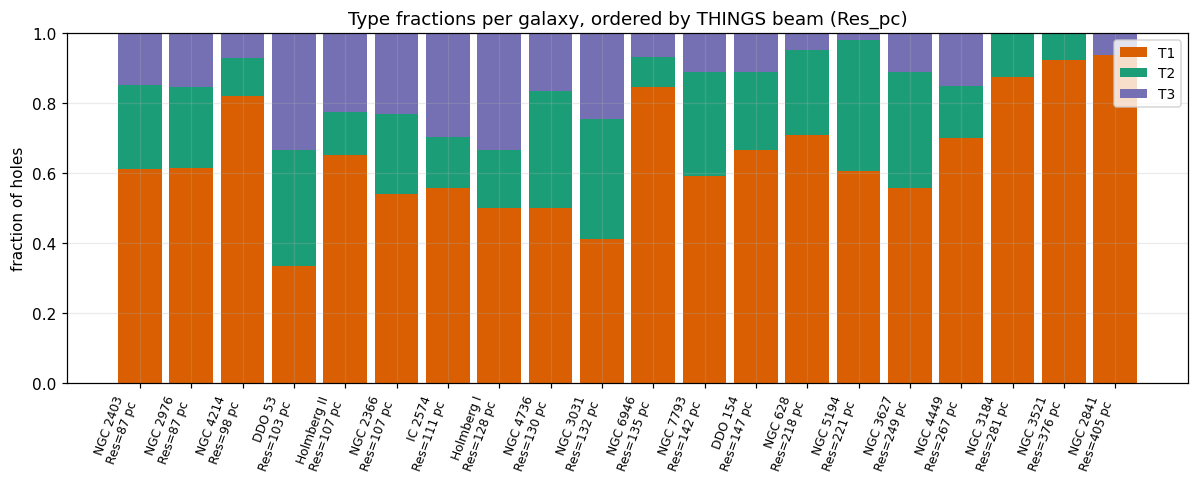

Spearman rho(T1 fraction, Res_pc)   = +0.48  (p = 3.08e-02)
Spearman rho(T1 fraction, Dist_Mpc) = +0.45  (p = 4.81e-02)


In [16]:
# fraction of each Type within every galaxy, joined to resolution and distance
type_frac_by_galaxy = (df.groupby(["Name", "shell_type"]).size()
                       .unstack(fill_value=0))
type_frac_by_galaxy = type_frac_by_galaxy.div(type_frac_by_galaxy.sum(axis=1), axis=0)
type_frac_by_galaxy = type_frac_by_galaxy.join(
    galaxies.set_index("Name")[["Res_pc", "Dist_Mpc"]], how="left"
).sort_values("Res_pc")

# stacked bar of Type fractions per galaxy, ordered by beam size
fig, ax = plt.subplots(figsize=(11, 4.5))
xpos = np.arange(len(type_frac_by_galaxy))
bottom = np.zeros(len(xpos))
for t in (1, 2, 3):
    vals = type_frac_by_galaxy[t].values if t in type_frac_by_galaxy.columns else np.zeros(len(xpos))
    ax.bar(xpos, vals, bottom=bottom, color=TYPE_COLORS[t], label=f"T{t}", width=0.85)
    bottom += vals
labels = [f"{name}\nRes={int(res)} pc" for name, res in
          zip(type_frac_by_galaxy.index, type_frac_by_galaxy["Res_pc"])]
ax.set_xticks(xpos); ax.set_xticklabels(labels, rotation=70, ha="right", fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel("fraction of holes")
ax.set_title("Type fractions per galaxy, ordered by THINGS beam (Res_pc)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "type_fractions_by_galaxy.png", **SAVE_KW)
plt.show()

# does the Type-1 fraction rise with coarser resolution / greater distance?
rho_res,  p_res  = st.spearmanr(type_frac_by_galaxy["Res_pc"],  type_frac_by_galaxy[1])
rho_dist, p_dist = st.spearmanr(type_frac_by_galaxy["Dist_Mpc"], type_frac_by_galaxy[1])
print(f"Spearman rho(T1 fraction, Res_pc)   = {rho_res:+.2f}  (p = {p_res:.2e})")
print(f"Spearman rho(T1 fraction, Dist_Mpc) = {rho_dist:+.2f}  (p = {p_dist:.2e})")

,model,beta(log_dpc_over_res),z,p
0,pooled,+2.95,+11.70,1.24e-31
1,galaxy fixed effects,+5.58,+9.88,4.98e-23
2,FE + log_nHI + R_kpc,+5.24,+9.01,2.14e-19


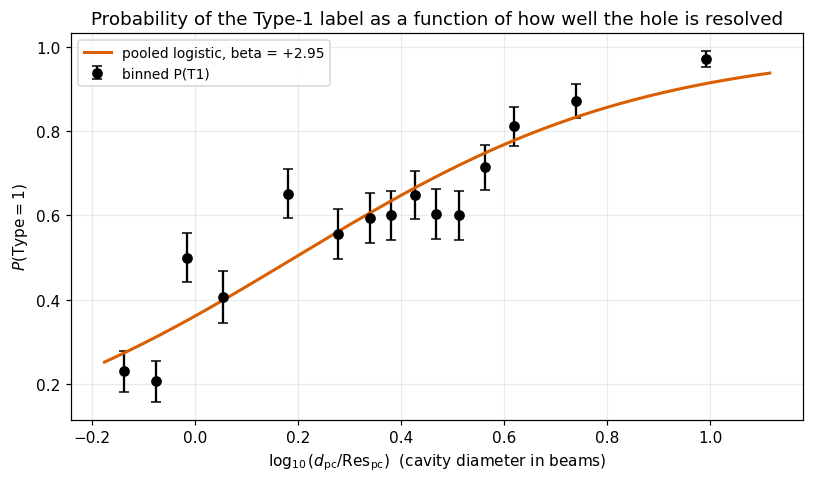

In [17]:
bias_frame = df.dropna(subset=["dpc_over_res", "Res_pc", "Dist_Mpc", "R_kpc", "log_nHI"]).copy()
bias_frame["is_type1"]         = (bias_frame["shell_type"] == 1).astype(int)
bias_frame["log_dpc_over_res"] = np.log10(bias_frame["dpc_over_res"])

# three nested models: pooled, + galaxy fixed effects, + physical controls
pooled  = smf.logit("is_type1 ~ log_dpc_over_res", data=bias_frame).fit(disp=0)
fe      = smf.logit("is_type1 ~ log_dpc_over_res + C(Name)", data=bias_frame).fit(disp=0)
fe_ctrl = smf.logit("is_type1 ~ log_dpc_over_res + log_nHI + R_kpc + C(Name)", data=bias_frame).fit(disp=0)

logit_summary = pd.DataFrame({
    "model": ["pooled", "galaxy fixed effects", "FE + log_nHI + R_kpc"],
    "beta(log_dpc_over_res)": [pooled.params["log_dpc_over_res"],
                               fe.params["log_dpc_over_res"],
                               fe_ctrl.params["log_dpc_over_res"]],
    "z": [pooled.tvalues["log_dpc_over_res"],
          fe.tvalues["log_dpc_over_res"],
          fe_ctrl.tvalues["log_dpc_over_res"]],
    "p": [pooled.pvalues["log_dpc_over_res"],
          fe.pvalues["log_dpc_over_res"],
          fe_ctrl.pvalues["log_dpc_over_res"]],
})
display(logit_summary.style.format({
    "beta(log_dpc_over_res)": "{:+.2f}", "z": "{:+.2f}", "p": "{:.2e}"
}))

# plot the fitted curve against the empirical P(T1) in equal-count bins
xs = np.linspace(bias_frame["log_dpc_over_res"].quantile(0.01),
                 bias_frame["log_dpc_over_res"].quantile(0.99), 200)
preds = pooled.predict(pd.DataFrame({"log_dpc_over_res": xs}))
bias_frame["bin"] = pd.qcut(bias_frame["log_dpc_over_res"], q=15, duplicates="drop")
binned = bias_frame.groupby("bin", observed=True).agg(
    x=("log_dpc_over_res", "mean"),
    p=("is_type1", "mean"),
    n=("is_type1", "size"),
).reset_index(drop=True)
binned["se"] = np.sqrt(binned["p"] * (1 - binned["p"]) / binned["n"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(binned["x"], binned["p"], yerr=binned["se"], fmt="o",
            color="black", capsize=3, label="binned P(T1)")
ax.plot(xs, preds, color=TYPE_COLORS[1], lw=2,
        label=f"pooled logistic, beta = {pooled.params['log_dpc_over_res']:+.2f}")
ax.set_xlabel(r"$\log_{10}(d_{\mathrm{pc}} / \mathrm{Res}_{\mathrm{pc}})$  (cavity diameter in beams)")
ax.set_ylabel(r"$P(\mathrm{Type} = 1)$")
ax.set_title("Probability of the Type-1 label as a function of how well the hole is resolved")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "pt1_vs_resolution.png", **SAVE_KW)
plt.show()

## 4. Are the labels recoverable?

If the Types are genuinely distinct, we should be able to recover them from the $V_{\mathrm{exp}}$-independent features (so we drop $t_{\mathrm{kin}}$ and $\log E$).

- **Unsupervised**: cluster on the physical features and see whether BIC prefers $K=3$ and whether the clusters line up with the Types (ARI, NMI). They don't. BIC picks $K=5$ and $\mathrm{ARI}\approx0.02$, basically chance.
- **Supervised**: a galaxy-stratified random forest (`GroupKFold`), full features against a detectability-only baseline, scored by the gap $\Delta_{\mathrm{acc}} = \mathrm{acc}(\text{full}) - \mathrm{acc}(\text{detectability})$. The gap is tiny ($\Delta_{\mathrm{acc}}=+0.04$) and both models land below the majority-class baseline.

In [18]:
# V_exp-independent physical features only; standardize so each has comparable scale
PHYS_ONLY = ["log_d_pc", "axis_ratio", "R_kpc", "log_nHI", "log_MHI"]
X_raw = df[PHYS_ONLY + ["shell_type", "Name"]].dropna(subset=PHYS_ONLY + ["shell_type"]).copy()
y      = X_raw["shell_type"].astype(int).values
groups = X_raw["Name"].values

X = StandardScaler().fit_transform(X_raw[PHYS_ONLY].values)

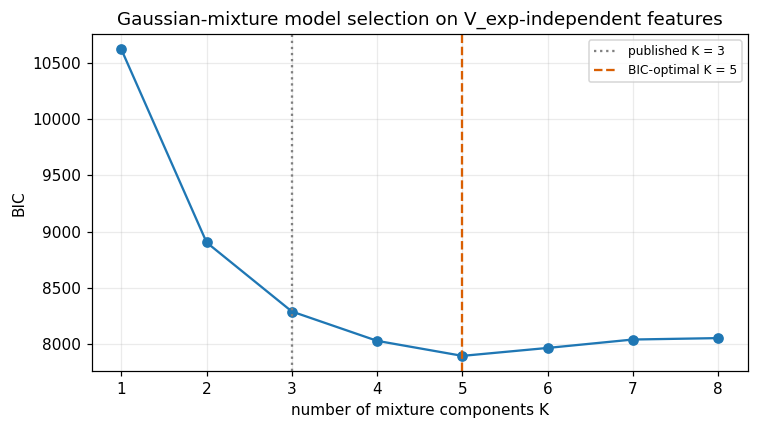

BIC-optimal K          = 5
ARI(Type, GMM best-K)  = +0.018    NMI = 0.055
ARI(Type, GMM K = 3 forced) = +0.007    NMI = 0.045


In [23]:
# fit Gaussian mixtures for K = 1..8 and pick the K with the lowest BIC
K_RANGE = range(1, 9)
bic = np.array([
    GaussianMixture(n_components=k, covariance_type="full",
                    n_init=4, random_state=0).fit(X).bic(X)
    for k in K_RANGE
])
best_k = int(list(K_RANGE)[int(np.argmin(bic))])

gmm_best = GaussianMixture(n_components=best_k, covariance_type="full",
                            n_init=8, random_state=0).fit(X)
gmm_k3   = GaussianMixture(n_components=3, covariance_type="full",
                            n_init=8, random_state=0).fit(X)

# ARI / NMI measure how much the clusters overlap the published Types (0 = chance)
ari_best = adjusted_rand_score(y, gmm_best.predict(X))
nmi_best = normalized_mutual_info_score(y, gmm_best.predict(X))
ari_k3   = adjusted_rand_score(y, gmm_k3.predict(X))
nmi_k3   = normalized_mutual_info_score(y, gmm_k3.predict(X))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), bic, "o-")
ax.axvline(3, color="grey", ls=":", label="published K = 3")
ax.axvline(best_k, color=TYPE_COLORS[1], ls="--", label=f"BIC-optimal K = {best_k}")
ax.set_xlabel("number of mixture components K")
ax.set_ylabel("BIC")
ax.set_title("Gaussian-mixture model selection on V_exp-independent features")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "gmm_bic_vs_k.png", **SAVE_KW)
plt.show()

print(f"BIC-optimal K          = {best_k}")
print(f"ARI(Type, GMM best-K)  = {ari_best:+.3f}    NMI = {nmi_best:.3f}")
print(f"ARI(Type, GMM K = 3 forced) = {ari_k3:+.3f}    NMI = {nmi_k3:.3f}")

Galaxy-stratified 5-fold random-forest accuracy:
  full feature set         : 0.568   (macro F1 = 0.416)   per-fold 0.592 +/- 0.100
  detectability baseline   : 0.531   (macro F1 = 0.391)   per-fold 0.554 +/- 0.126
  majority-class baseline  : 0.598
  Delta_accuracy           : +0.037  (per-fold std ~ 0.126)


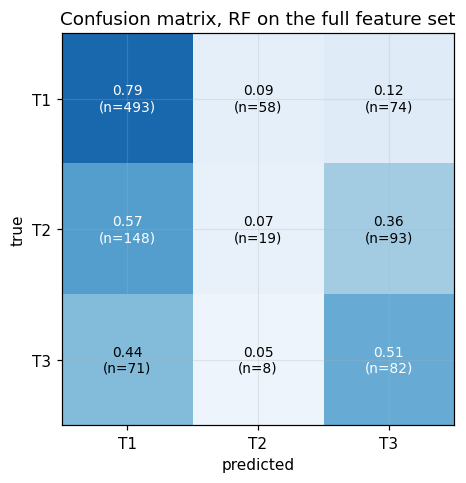

In [20]:
# full physical+detectability features vs a detectability-only baseline
FULL_FEATS = ["log_d_pc", "axis_ratio", "R_kpc", "log_nHI", "log_MHI",
              "dpc_over_res", "Res_pc", "Dist_Mpc"]
OBS_FEATS  = ["log_d_pc", "dpc_over_res", "Res_pc", "Dist_Mpc"]
clf_frame = df.dropna(subset=FULL_FEATS + ["shell_type"]).copy()
yc = clf_frame["shell_type"].astype(int).values
gc = clf_frame["Name"].values

# GroupKFold keeps each galaxy entirely in train or test, never split across both
def rf_cv(X_in):
    cv     = GroupKFold(n_splits=5)
    rf     = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1)
    yp     = cross_val_predict(rf, X_in, yc, groups=gc, cv=cv)
    folds  = cross_val_score(rf, X_in, yc, groups=gc, cv=cv, scoring="accuracy")
    return yp, accuracy_score(yc, yp), f1_score(yc, yp, average="macro"), folds

y_full, acc_full, f1_full, folds_full = rf_cv(clf_frame[FULL_FEATS].values)
y_obs,  acc_obs,  f1_obs,  folds_obs  = rf_cv(clf_frame[OBS_FEATS].values)
acc_base = max((yc == t).mean() for t in (1, 2, 3))

print("Galaxy-stratified 5-fold random-forest accuracy:")
print(f"  full feature set         : {acc_full:.3f}   (macro F1 = {f1_full:.3f})   "
      f"per-fold {folds_full.mean():.3f} +/- {folds_full.std():.3f}")
print(f"  detectability baseline   : {acc_obs:.3f}   (macro F1 = {f1_obs:.3f})   "
      f"per-fold {folds_obs.mean():.3f} +/- {folds_obs.std():.3f}")
print(f"  majority-class baseline  : {acc_base:.3f}")
print(f"  Delta_accuracy           : {acc_full - acc_obs:+.3f}  "
      f"(per-fold std ~ {max(folds_full.std(), folds_obs.std()):.3f})")

# row-normalized confusion matrix: where does each true Type get predicted?
cm_full = confusion_matrix(yc, y_full, labels=[1, 2, 3])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cmn = cm_full / cm_full.sum(axis=1, keepdims=True)
ax.imshow(cmn, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["T1", "T2", "T3"]); ax.set_yticklabels(["T1", "T2", "T3"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cmn[i,j]:.2f}\n(n={cm_full[i,j]})", ha="center", va="center",
                color="white" if cmn[i, j] > 0.5 else "black", fontsize=9)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix, RF on the full feature set")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "rf_confusion_matrix.png", **SAVE_KW)
plt.show()

## 5. B11's stall-floor claim, re-examined

B11 set Type-1 $V_{\mathrm{exp}} = \sigma_{\mathrm{gas}} \approx 7$ to $10$ km/s, assuming those holes have stalled. If the Types were really distinct, the *measured* T2/T3 velocities should sit well above this floor instead of piling up against it.

- Overlay the $\sigma_{\mathrm{gas}}$ band and report the fraction at or below 10 km/s. They pile up: 39% of T2 and 55% of T3 land inside the band, which looks like a continuum cut off by gas dispersion rather than a clean split.

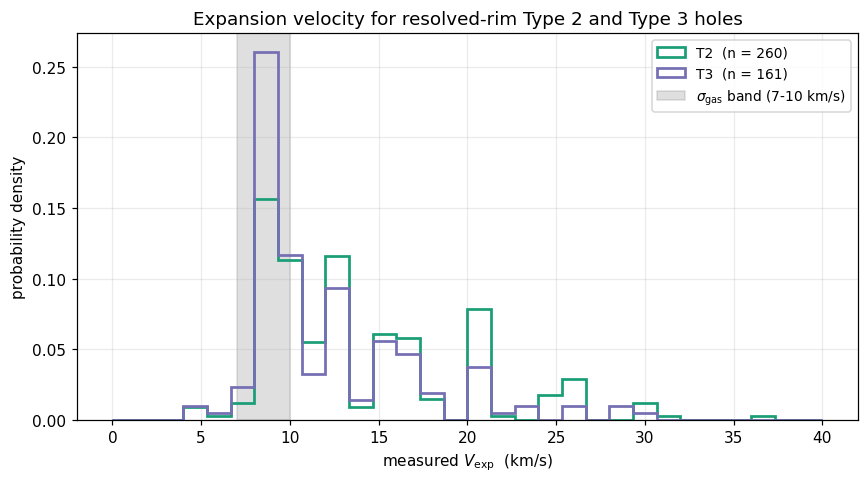

Fraction of Type 2 with measured V_exp <= 10 km/s (at/below top of sigma_gas band): 38.8%
Fraction of Type 3 with measured V_exp <= 10 km/s (at/below top of sigma_gas band): 55.3%


In [21]:
# histogram of measured V_exp for T2/T3, with the sigma_gas stall band shaded
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 40, 31)
for t in (2, 3):
    sub = df.loc[df["shell_type"] == t, "vexp_measured_kms"].dropna()
    ax.hist(sub, bins=bins, density=True, histtype="step", lw=1.8,
            color=TYPE_COLORS[t], label=f"T{t}  (n = {len(sub)})")
ax.axvspan(7, 10, color="grey", alpha=0.25,
            label=r"$\sigma_{\mathrm{gas}}$ band (7-10 km/s)")
ax.set_xlabel(r"measured $V_{\mathrm{exp}}$  (km/s)")
ax.set_ylabel("probability density")
ax.set_title("Expansion velocity for resolved-rim Type 2 and Type 3 holes")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "vexp_stall_histogram.png", **SAVE_KW)
plt.show()

# fraction of measured holes sitting at/below the top of the band (10 km/s)
below_floor_t2 = float((df.loc[df["shell_type"] == 2, "vexp_measured_kms"] <= 10).mean())
below_floor_t3 = float((df.loc[df["shell_type"] == 3, "vexp_measured_kms"] <= 10).mean())
print(f"Fraction of Type 2 with measured V_exp <= 10 km/s (at/below top of sigma_gas band): {below_floor_t2:.1%}")
print(f"Fraction of Type 3 with measured V_exp <= 10 km/s (at/below top of sigma_gas band): {below_floor_t3:.1%}")

## 6. Verdict and recommendation

Tally the five tests. Each one returns `distinct`, `partial` (Type 1 splits off from {2,3} but 2 and 3 don't), or `not distinct`, and then the code turns the tally into a pipeline action. The cutoffs (set as constants in the code) are:

- **Sec 2 (T2 vs T3)**: `distinct` if any clean feature separates them at $q<0.05$ and $|\delta|\ge0.15$.
- **Sec 3 (selection)**: `not distinct` if the pooled fit has $p<0.001$ and $|\beta|>0.5$; `partial` if $p<0.05$ and $|\beta|>0.1$.
- **Sec 4 (unsupervised)**: `not distinct` if $K\ne3$ and $\mathrm{ARI}<0.05$; `distinct` if $K=3$ and $\mathrm{ARI}>0.2$.
- **Sec 4 (supervised)**: based on $\Delta_{\mathrm{acc}}$, where below $0.03$ is `not distinct`, below $0.10$ is `partial`, otherwise `distinct`.
- **Sec 5 (stall floor)**: based on the T2 fraction in the band, where above $0.40$ is `not distinct`, above $0.25$ is `partial`, otherwise `distinct`.

In [22]:
# each verdict_* applies the Section's cutoffs and returns distinct / partial / not distinct
def verdict_2v3() -> str:
    return "distinct" if T2v3_clean else (
        "not distinct (no T2-vs-T3 separation in V_exp-independent features)"
    )

def verdict_bias() -> str:
    beta = pooled.params["log_dpc_over_res"]
    pval = pooled.pvalues["log_dpc_over_res"]
    if pval < 0.001 and abs(beta) > 0.5:
        return f"not distinct (strong detectability dependence, beta = {beta:+.2f})"
    if pval < 0.05 and abs(beta) > 0.1:
        return f"partial (detectability matters, beta = {beta:+.2f})"
    return "distinct (no detectability dependence)"

def verdict_unsup() -> str:
    if best_k != 3 and ari_best < 0.05:
        return f"not distinct (BIC prefers K = {best_k}, ARI = {ari_best:+.2f})"
    if best_k == 3 and ari_best > 0.2:
        return "distinct"
    return f"partial (BIC K = {best_k}, ARI = {ari_best:+.2f})"

def verdict_supervised() -> str:
    delta = acc_full - acc_obs
    if delta < 0.03:
        return f"not distinct (Delta_accuracy = {delta:+.2%})"
    if delta < 0.10:
        return f"partial (Delta_accuracy = {delta:+.2%})"
    return f"distinct (Delta_accuracy = {delta:+.2%})"

def verdict_stall() -> str:
    if below_floor_t2 > 0.40:
        return f"not distinct (T2 pile-up at sigma_gas: {below_floor_t2:.0%})"
    if below_floor_t2 > 0.25:
        return f"partial (T2 inside band: {below_floor_t2:.0%})"
    return "distinct"

verdict_rows = [
    ("Sec 2  Type 2 vs Type 3 in V_exp-independent features",  verdict_2v3()),
    ("Sec 3  P(T1 | dpc_over_res) selection dependence",       verdict_bias()),
    ("Sec 4  Unsupervised structure prefers K = 3",            verdict_unsup()),
    ("Sec 4  Full features beat detectability baseline",       verdict_supervised()),
    ("Sec 5  T2 V_exp distribution sits above sigma_gas band", verdict_stall()),
]
display(pd.DataFrame(verdict_rows, columns=["test", "verdict"]))

# tally the five verdicts and turn the count into a concrete pipeline recommendation
distinct     = sum(v.startswith("distinct")     for _, v in verdict_rows)
partial      = sum(v.startswith("partial")      for _, v in verdict_rows)
not_distinct = sum(v.startswith("not distinct") for _, v in verdict_rows)

if not_distinct >= 3:
    recommendation = (
        "Collapse Types 2 and 3 into one binary 'measurable-expansion' class versus "
        "Type 1 for the downstream pipeline. The catalog labels are dominated by a "
        "detectability cut and do not encode three physical populations."
    )
elif not_distinct + partial >= 3 and distinct < 2:
    recommendation = (
        "Treat the Type label as auxiliary metadata, not as a training target. "
        "Use it for stratification (so Type 1 is not all in one fold) but not as a "
        "classification objective in the loss head."
    )
else:
    recommendation = (
        "Keep all three Types as targets; the evidence supports them as distinct "
        "(or at least near-distinct) populations beyond what detectability explains."
    )

print(f"Verdict tally: distinct = {distinct}, partial = {partial}, not_distinct = {not_distinct}\n")
print("Recommendation")
print("-" * 78)
print(recommendation)

,test,verdict
0,Sec 2 Type 2 vs Type 3 in V_exp-independent f...,distinct
1,Sec 3 P(T1 | dpc_over_res) selection dependence,"not distinct (strong detectability dependence,..."
2,Sec 4 Unsupervised structure prefers K = 3,"not distinct (BIC prefers K = 5, ARI = +0.02)"
3,Sec 4 Full features beat detectability baseline,partial (Delta_accuracy = +3.73%)
4,Sec 5 T2 V_exp distribution sits above sigma_...,partial (T2 inside band: 39%)


Verdict tally: distinct = 1, partial = 2, not_distinct = 2

Recommendation
------------------------------------------------------------------------------
Treat the Type label as auxiliary metadata, not as a training target. Use it for stratification (so Type 1 is not all in one fold) but not as a classification objective in the loss head.
